# Week 8: Evaluation Framework Test

This notebook tests the complete Phase 4 evaluation framework:

1. **BenchmarkDataset** - Load and filter evaluation examples
2. **EvaluationMetrics** - Test all 8 metrics (including FIXED hallucination_rate)
3. **StatisticalAnalysis** - Significance testing
4. **BaselineRunner** - Run all 7 baseline methods
5. **ExperimentRunner** - Full evaluation pipeline

---

## Setup Instructions

1. Upload this notebook to Colab
2. Enable GPU: Runtime → Change runtime type → T4 GPU
3. Run cells 1-3 to install deps and upload files
4. Upload files in 5 batches (entropy, retrieval, generation, evaluation, benchmark)
5. Run remaining cells

In [1]:
# Cell 1: Install dependencies
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn sentence-transformers

In [2]:
# Cell 2: Create directory structure
import os
import shutil

# Create module structure
os.makedirs('/content/orchestrator/entropy', exist_ok=True)
os.makedirs('/content/orchestrator/retrieval', exist_ok=True)
os.makedirs('/content/orchestrator/generation', exist_ok=True)
os.makedirs('/content/orchestrator/evaluation', exist_ok=True)
os.makedirs('/content/benchmarks', exist_ok=True)

# Create root __init__.py
with open('/content/orchestrator/__init__.py', 'w') as f:
    f.write('"""Orchestrator package."""\n')

print("Directory structure created:")
print("  /content/orchestrator/")
print("  /content/orchestrator/entropy/")
print("  /content/orchestrator/retrieval/")
print("  /content/orchestrator/generation/")
print("  /content/orchestrator/evaluation/")
print("  /content/benchmarks/")

Directory structure created:
  /content/orchestrator/
  /content/orchestrator/entropy/
  /content/orchestrator/retrieval/
  /content/orchestrator/generation/
  /content/orchestrator/evaluation/
  /content/benchmarks/


In [3]:
# Cell 3: Upload all module files
from google.colab import files

def upload_to_dir(target_dir):
    """Upload files and move to target directory."""
    uploaded = files.upload()
    for filename in uploaded.keys():
        if filename.endswith('.py') or filename.endswith('.json'):
            dest = f'{target_dir}/{filename}'
            shutil.move(filename, dest)
            print(f"  ✓ {filename}")
    return uploaded

# ============================================================
print("="*60)
print("STEP 1/5: Upload ENTROPY module files (7 files)")
print("="*60)
print("\nFrom: packages/python-orchestrator/orchestrator/entropy/")
print("Upload: __init__.py, calculator.py, cce_computer.py, token_classifier.py,")
print("        measurement.py, monitor.py, spike_detector.py")
upload_to_dir('/content/orchestrator/entropy')

# ============================================================
print("\n" + "="*60)
print("STEP 2/5: Upload RETRIEVAL module files (4 files)")
print("="*60)
print("\nFrom: packages/python-orchestrator/orchestrator/retrieval/")
print("Upload: __init__.py, topic_inference.py, adaptive.py, context_manager.py")
upload_to_dir('/content/orchestrator/retrieval')

# ============================================================
print("\n" + "="*60)
print("STEP 3/5: Upload GENERATION module files (2 files)")
print("="*60)
print("\nFrom: packages/python-orchestrator/orchestrator/generation/")
print("Upload: __init__.py, adaptive_generator.py")
upload_to_dir('/content/orchestrator/generation')

# ============================================================
print("\n" + "="*60)
print("STEP 4/5: Upload EVALUATION module files (5 files)")
print("="*60)
print("\nFrom: packages/python-orchestrator/orchestrator/evaluation/")
print("Upload: __init__.py, benchmark.py, metrics.py, runner.py, stats.py")
upload_to_dir('/content/orchestrator/evaluation')

# ============================================================
print("\n" + "="*60)
print("STEP 5/5: Upload BENCHMARK file (1 file)")
print("="*60)
print("\nFrom: research/benchmarks/")
print("Upload: benchmark_v1.json")
upload_to_dir('/content/benchmarks')

# ============================================================
print("\n" + "="*60)
print("VERIFICATION")
print("="*60)
print("\nEvaluation module:")
!ls /content/orchestrator/evaluation/
print("\nBenchmarks:")
!ls /content/benchmarks/

STEP 1/5: Upload ENTROPY module files (7 files)

From: packages/python-orchestrator/orchestrator/entropy/
Upload: __init__.py, calculator.py, cce_computer.py, token_classifier.py,
        measurement.py, monitor.py, spike_detector.py


Saving __init__.py to __init__.py
Saving calculator.py to calculator.py
Saving cce_computer.py to cce_computer.py
Saving measurement.py to measurement.py
Saving monitor.py to monitor.py
Saving spike_detector.py to spike_detector.py
Saving token_classifier.py to token_classifier.py
  ✓ __init__.py
  ✓ calculator.py
  ✓ cce_computer.py
  ✓ measurement.py
  ✓ monitor.py
  ✓ spike_detector.py
  ✓ token_classifier.py

STEP 2/5: Upload RETRIEVAL module files (4 files)

From: packages/python-orchestrator/orchestrator/retrieval/
Upload: __init__.py, topic_inference.py, adaptive.py, context_manager.py


Saving __init__.py to __init__.py
Saving adaptive.py to adaptive.py
Saving context_manager.py to context_manager.py
Saving topic_inference.py to topic_inference.py
  ✓ __init__.py
  ✓ adaptive.py
  ✓ context_manager.py
  ✓ topic_inference.py

STEP 3/5: Upload GENERATION module files (2 files)

From: packages/python-orchestrator/orchestrator/generation/
Upload: __init__.py, adaptive_generator.py


Saving __init__.py to __init__.py
Saving adaptive_generator.py to adaptive_generator.py
  ✓ __init__.py
  ✓ adaptive_generator.py

STEP 4/5: Upload EVALUATION module files (5 files)

From: packages/python-orchestrator/orchestrator/evaluation/
Upload: __init__.py, benchmark.py, metrics.py, runner.py, stats.py


Saving __init__.py to __init__.py
Saving benchmark.py to benchmark.py
Saving metrics.py to metrics.py
Saving runner.py to runner.py
Saving stats.py to stats.py
  ✓ __init__.py
  ✓ benchmark.py
  ✓ metrics.py
  ✓ runner.py
  ✓ stats.py

STEP 5/5: Upload BENCHMARK file (1 file)

From: research/benchmarks/
Upload: benchmark_v1.json


Saving benchmark_v1.json to benchmark_v1.json
  ✓ benchmark_v1.json

VERIFICATION

Evaluation module:
benchmark.py  __init__.py  metrics.py  runner.py  stats.py

Benchmarks:
benchmark_v1.json


In [4]:
# Cell 4: Imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict

sys.path.insert(0, '/content')

import warnings
warnings.filterwarnings('ignore')

print("Base imports complete")

Base imports complete


In [5]:
# Cell 5: Import evaluation modules
from orchestrator.evaluation import (
    BenchmarkDataset,
    BenchmarkExample,
    EvaluationMetrics,
    EvaluationResult,
    StatisticalAnalysis,
    BaselineMethod,
    create_sample_benchmark,
)
from orchestrator.evaluation.benchmark import Difficulty, Category
from orchestrator.evaluation.runner import (
    BaselineRunner,
    ExperimentRunner,
    EvaluationRetriever,
)

print("✓ All evaluation modules imported successfully!")
print("")
print("Available components:")
print("  • BenchmarkDataset - structured evaluation examples")
print("  • EvaluationMetrics - 8 metrics for assessment")
print("  • StatisticalAnalysis - significance testing")
print("  • BaselineRunner - run baseline methods")
print("  • ExperimentRunner - full experiment orchestration")

✓ All evaluation modules imported successfully!

Available components:
  • BenchmarkDataset - structured evaluation examples
  • EvaluationMetrics - 8 metrics for assessment
  • StatisticalAnalysis - significance testing
  • BaselineRunner - run baseline methods
  • ExperimentRunner - full experiment orchestration


---
## 1. Test Benchmark Dataset

In [6]:
# Cell 6: Load benchmark from file
benchmark_path = Path('/content/benchmarks/benchmark_v1.json')

if benchmark_path.exists():
    benchmark = BenchmarkDataset.load(benchmark_path)
    print(f"Loaded benchmark from file: {benchmark_path}")
else:
    benchmark = create_sample_benchmark()
    print("Using sample benchmark (file not found)")

print("\nBenchmark Dataset")
print("="*60)
print(f"Name: {benchmark.name}")
print(f"Version: {benchmark.version}")
print(f"Examples: {len(benchmark)}")

print("\nStatistics:")
stats = benchmark.get_statistics()
print(f"  By difficulty: {stats['by_difficulty']}")
print(f"  By category: {stats['by_category']}")
print(f"  Avg ground truth files: {stats['avg_ground_truth_files']:.1f}")

print("\nFirst 5 Examples:")
for ex in list(benchmark)[:5]:
    print(f"\n  [{ex.id}] {ex.difficulty.value} | {ex.category.value}")
    print(f"  Query: {ex.query[:60]}...")
    print(f"  Files: {ex.ground_truth_files}")

Loaded benchmark from file: /content/benchmarks/benchmark_v1.json

Benchmark Dataset
Name: reposynth_benchmark_v1
Version: 1.0.0
Examples: 15

Statistics:
  By difficulty: {'medium': 7, 'hard': 2, 'easy': 6}
  By category: {'architecture': 4, 'api_usage': 7, 'configuration': 2, 'implementation': 2}
  Avg ground truth files: 2.0

First 5 Examples:

  [flask_001] medium | architecture
  Query: How does Flask handle URL routing and decorators?...
  Files: ['src/flask/app.py', 'src/flask/scaffold.py']

  [flask_002] hard | architecture
  Query: How does Flask's request context work?...
  Files: ['src/flask/ctx.py', 'src/flask/globals.py', 'src/flask/app.py']

  [flask_003] medium | api_usage
  Query: What are Flask Blueprints and how do they work?...
  Files: ['src/flask/blueprints.py', 'src/flask/scaffold.py']

  [flask_004] easy | configuration
  Query: How do I configure a Flask application?...
  Files: ['src/flask/config.py']

  [flask_005] easy | implementation
  Query: How do I handl

In [7]:
# Cell 7: Test filtering and validation
print("Filtering & Validation")
print("="*60)

# Filter by difficulty
easy = benchmark.filter(difficulty=Difficulty.EASY)
medium = benchmark.filter(difficulty=Difficulty.MEDIUM)
hard = benchmark.filter(difficulty=Difficulty.HARD)
print(f"By difficulty: easy={len(easy)}, medium={len(medium)}, hard={len(hard)}")

# Filter by category
arch = benchmark.filter(category=Category.ARCHITECTURE)
api = benchmark.filter(category=Category.API_USAGE)
print(f"By category: architecture={len(arch)}, api_usage={len(api)}")

# Validate dataset
errors = benchmark.validate()
print(f"\nValidation errors: {len(errors)}")
if errors:
    for err in errors[:5]:
        print(f"  - {err}")

Filtering & Validation
By difficulty: easy=6, medium=7, hard=2
By category: architecture=4, api_usage=7

Validation errors: 0


---
## 2. Test Evaluation Metrics (All 8)

In [8]:
# Cell 8: Create metrics evaluator
metrics = EvaluationMetrics(embedding_model='all-MiniLM-L6-v2')

print("EvaluationMetrics initialized")
print("="*60)
print("8 Metrics available:")
print("  1. answer_correctness - LLM/keyword scoring")
print("  2. answer_completeness - semantic similarity")
print("  3. hallucination_rate - unsupported claims (FIXED!)")
print("  4. context_precision - retrieved accuracy")
print("  5. context_recall - coverage of truth")
print("  6. token_efficiency - tokens saved")
print("  7. spike_precision - trigger accuracy (NEW!)")
print("  8. spike_recall - trigger coverage (NEW!)")

EvaluationMetrics initialized
8 Metrics available:
  1. answer_correctness - LLM/keyword scoring
  2. answer_completeness - semantic similarity
  3. hallucination_rate - unsupported claims (FIXED!)
  4. context_precision - retrieved accuracy
  5. context_recall - coverage of truth
  6. token_efficiency - tokens saved
  7. spike_precision - trigger accuracy (NEW!)
  8. spike_recall - trigger coverage (NEW!)


In [9]:
# Cell 9: Test answer metrics

# Test data
ground_truth = """User authentication uses JWT tokens. The user logs in via /login endpoint.
The server creates a JWT token with create_token() function.
The token is verified using verify_token() on protected routes."""

good_answer = """Authentication is implemented using JWT tokens.
Users log in at the /login endpoint which calls create_token().
Protected routes use verify_token() to authenticate requests."""

bad_answer = """The system uses cookies for session management.
Users are authenticated through OAuth2 with Google.
There is no password-based authentication."""

keywords = ["JWT", "token", "login", "create_token", "verify_token"]

print("Answer Metrics Test")
print("="*60)

# Answer completeness
good_completeness = metrics.answer_completeness(good_answer, ground_truth)
bad_completeness = metrics.answer_completeness(bad_answer, ground_truth)
print(f"\nAnswer Completeness (semantic similarity):")
print(f"  Good answer: {good_completeness:.3f}")
print(f"  Bad answer:  {bad_completeness:.3f}")

# Answer correctness
good_correct = metrics.answer_correctness(good_answer, ground_truth, keywords)
bad_correct = metrics.answer_correctness(bad_answer, ground_truth, keywords)
print(f"\nAnswer Correctness (keywords + semantic):")
print(f"  Good answer: {good_correct:.3f}")
print(f"  Bad answer:  {bad_correct:.3f}")

Answer Metrics Test


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Answer Completeness (semantic similarity):
  Good answer: 0.910
  Bad answer:  0.600

Answer Correctness (keywords + semantic):
  Good answer: 0.946
  Bad answer:  0.360


In [10]:
# Cell 10: Test FIXED hallucination rate
print("Hallucination Rate Test (FIXED!)")
print("="*60)

# Good answer - should have LOW hallucination rate
good_halluc = metrics.hallucination_rate(good_answer, ground_truth, keywords)

# Bad answer - should have HIGH hallucination rate
bad_halluc = metrics.hallucination_rate(bad_answer, ground_truth, keywords)

print(f"\nHallucination Rate (lower is better):")
print(f"  Good answer: {good_halluc:.3f}")
print(f"  Bad answer:  {bad_halluc:.3f}")

# Verify the fix works
if bad_halluc > good_halluc:
    print("\n✓ FIXED: Bad answer correctly has higher hallucination rate!")
else:
    print("\n✗ WARNING: Hallucination detection may need tuning")

print("\nNote: Previously this returned 0.0 for both. Now it properly")
print("      extracts claims and checks semantic support.")

Hallucination Rate Test (FIXED!)

Hallucination Rate (lower is better):
  Good answer: 0.000
  Bad answer:  1.000

✓ FIXED: Bad answer correctly has higher hallucination rate!

Note: Previously this returned 0.0 for both. Now it properly
      extracts claims and checks semantic support.


In [11]:
# Cell 11: Test context metrics
print("Context Metrics Test")
print("="*60)

ground_truth_files = ["src/auth/jwt.py", "src/api/routes.py"]

# Scenario 1: Perfect retrieval
perfect_retrieved = ["src/auth/jwt.py", "src/api/routes.py"]
precision_1 = metrics.context_precision(perfect_retrieved, ground_truth_files)
recall_1 = metrics.context_recall(perfect_retrieved, ground_truth_files)

# Scenario 2: Partial retrieval (missed one)
partial_retrieved = ["src/auth/jwt.py"]
precision_2 = metrics.context_precision(partial_retrieved, ground_truth_files)
recall_2 = metrics.context_recall(partial_retrieved, ground_truth_files)

# Scenario 3: Over-retrieval (extra files)
over_retrieved = ["src/auth/jwt.py", "src/api/routes.py", "src/config.py", "src/utils.py"]
precision_3 = metrics.context_precision(over_retrieved, ground_truth_files)
recall_3 = metrics.context_recall(over_retrieved, ground_truth_files)

print(f"\nGround truth files: {ground_truth_files}")

print(f"\nScenario 1 - Perfect retrieval {perfect_retrieved}:")
print(f"  Precision: {precision_1:.2f}, Recall: {recall_1:.2f}")

print(f"\nScenario 2 - Partial retrieval {partial_retrieved}:")
print(f"  Precision: {precision_2:.2f}, Recall: {recall_2:.2f}")

print(f"\nScenario 3 - Over-retrieval {over_retrieved}:")
print(f"  Precision: {precision_3:.2f}, Recall: {recall_3:.2f}")

Context Metrics Test

Ground truth files: ['src/auth/jwt.py', 'src/api/routes.py']

Scenario 1 - Perfect retrieval ['src/auth/jwt.py', 'src/api/routes.py']:
  Precision: 1.00, Recall: 1.00

Scenario 2 - Partial retrieval ['src/auth/jwt.py']:
  Precision: 1.00, Recall: 0.50

Scenario 3 - Over-retrieval ['src/auth/jwt.py', 'src/api/routes.py', 'src/config.py', 'src/utils.py']:
  Precision: 0.50, Recall: 1.00


In [12]:
# Cell 12: Test NEW spike detection metrics
print("Spike Detection Metrics Test (NEW!)")
print("="*60)

# Ground truth: positions where context was missing
ground_truth_positions = [10, 25, 45, 70]

# Scenario 1: Perfect detection
detected_1 = [10, 25, 45, 70]
prec_1 = metrics.spike_precision(detected_1, ground_truth_positions, tolerance=3)
rec_1 = metrics.spike_recall(detected_1, ground_truth_positions, tolerance=3)

# Scenario 2: Close but not exact (within tolerance)
detected_2 = [12, 27, 48, 72]  # All within tolerance=3
prec_2 = metrics.spike_precision(detected_2, ground_truth_positions, tolerance=3)
rec_2 = metrics.spike_recall(detected_2, ground_truth_positions, tolerance=3)

# Scenario 3: Missed some, false positives
detected_3 = [10, 25, 100, 150]  # 2 correct, 2 false positives
prec_3 = metrics.spike_precision(detected_3, ground_truth_positions, tolerance=3)
rec_3 = metrics.spike_recall(detected_3, ground_truth_positions, tolerance=3)

# Scenario 4: No detections
detected_4 = []
prec_4 = metrics.spike_precision(detected_4, ground_truth_positions, tolerance=3)
rec_4 = metrics.spike_recall(detected_4, ground_truth_positions, tolerance=3)

print(f"\nGround truth missing positions: {ground_truth_positions}")

print(f"\nScenario 1 - Perfect detection {detected_1}:")
print(f"  Precision: {prec_1:.2f}, Recall: {rec_1:.2f}")

print(f"\nScenario 2 - Close detection {detected_2}:")
print(f"  Precision: {prec_2:.2f}, Recall: {rec_2:.2f}")

print(f"\nScenario 3 - Partial with false positives {detected_3}:")
print(f"  Precision: {prec_3:.2f}, Recall: {rec_3:.2f}")

print(f"\nScenario 4 - No detections {detected_4}:")
print(f"  Precision: {prec_4:.2f}, Recall: {rec_4:.2f}")

Spike Detection Metrics Test (NEW!)

Ground truth missing positions: [10, 25, 45, 70]

Scenario 1 - Perfect detection [10, 25, 45, 70]:
  Precision: 1.00, Recall: 1.00

Scenario 2 - Close detection [12, 27, 48, 72]:
  Precision: 1.00, Recall: 1.00

Scenario 3 - Partial with false positives [10, 25, 100, 150]:
  Precision: 0.50, Recall: 0.50

Scenario 4 - No detections []:
  Precision: 0.00, Recall: 0.00


In [13]:
# Cell 13: Test token efficiency
print("Token Efficiency Test")
print("="*60)

baseline_tokens = 2000  # Full context

scenarios = [
    (500, "75% savings"),
    (1000, "50% savings"),
    (1500, "25% savings"),
    (2000, "No savings"),
    (2500, "Over budget"),
]

print(f"\nBaseline: {baseline_tokens} tokens")
print("\nEfficiency scores:")
for tokens_used, desc in scenarios:
    eff = metrics.token_efficiency(tokens_used, baseline_tokens)
    print(f"  {tokens_used:4d} tokens → {eff:.2f} ({desc})")

Token Efficiency Test

Baseline: 2000 tokens

Efficiency scores:
   500 tokens → 0.75 (75% savings)
  1000 tokens → 0.50 (50% savings)
  1500 tokens → 0.25 (25% savings)
  2000 tokens → 0.00 (No savings)
  2500 tokens → 0.00 (Over budget)


In [14]:
# Cell 14: Test full evaluation on benchmark example
example = benchmark[0]  # First example

result = metrics.evaluate(
    example_id=example.id,
    generated_answer=good_answer,
    ground_truth_answer=example.ground_truth_answer,
    retrieved_files=["src/auth/jwt.py", "src/api/routes.py"],
    ground_truth_files=example.ground_truth_files,
    ground_truth_keywords=example.ground_truth_keywords,
    tokens_used=500,
    baseline_tokens=2000,
    generation_time=2.5,
    num_retrievals=2,
    detected_positions=[12, 30, 50],
    ground_truth_positions=example.ground_truth_missing_positions,
    method="cce_adaptive",
)

print("Full Evaluation Result")
print("="*60)
print(f"\nExample: {result.example_id}")
print(f"Method: {result.method}")
print(f"\nAnswer Metrics:")
print(f"  Correctness:  {result.answer_correctness:.3f}")
print(f"  Completeness: {result.answer_completeness:.3f}")
print(f"  Hallucination:{result.hallucination_rate:.3f}")
print(f"\nContext Metrics:")
print(f"  Precision: {result.context_precision:.3f}")
print(f"  Recall:    {result.context_recall:.3f}")
print(f"  F1:        {result.get_f1_context():.3f}")
print(f"\nSpike Metrics:")
print(f"  Precision: {result.spike_precision:.3f}")
print(f"  Recall:    {result.spike_recall:.3f}")
print(f"  F1:        {result.get_f1_spike():.3f}")
print(f"\nEfficiency:")
print(f"  Token Efficiency: {result.token_efficiency:.3f}")
print(f"\nComposite Score: {result.get_composite_score():.3f}")

Full Evaluation Result

Example: flask_001
Method: cce_adaptive

Answer Metrics:
  Correctness:  0.397
  Completeness: 0.440
  Hallucination:0.667

Context Metrics:
  Precision: 0.000
  Recall:    0.000
  F1:        0.000

Spike Metrics:
  Precision: 0.667
  Recall:    0.500
  F1:        0.571

Efficiency:
  Token Efficiency: 0.750

Composite Score: 0.365


---
## 3. Test Statistical Analysis

In [15]:
# Cell 15: Test statistical analysis
stats_analyzer = StatisticalAnalysis(confidence=0.95)

print("Statistical Analysis Test")
print("="*60)

# Simulate scores from two methods
np.random.seed(42)
baseline_scores = np.random.normal(0.6, 0.1, 20)  # Mean 0.6
cce_scores = np.random.normal(0.75, 0.1, 20)      # Mean 0.75 (better)

# Paired t-test
t_stat, p_val = stats_analyzer.paired_t_test(list(cce_scores), list(baseline_scores))
print(f"\nPaired t-test:")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_val:.6f}")
print(f"  Significant: {'Yes' if p_val < 0.05 else 'No'}")

# Effect size
d = stats_analyzer.cohens_d(list(cce_scores), list(baseline_scores))
print(f"\nCohen's d effect size: {d:.3f}")
if abs(d) < 0.2:
    effect = "negligible"
elif abs(d) < 0.5:
    effect = "small"
elif abs(d) < 0.8:
    effect = "medium"
else:
    effect = "large"
print(f"  Interpretation: {effect} effect")

# Confidence interval
lower, upper = stats_analyzer.confidence_interval(list(cce_scores))
print(f"\n95% CI for CCE scores: [{lower:.3f}, {upper:.3f}]")

Statistical Analysis Test

Paired t-test:
  t-statistic: 4.285
  p-value: 0.000400
  Significant: Yes

Cohen's d effect size: 0.958
  Interpretation: large effect

95% CI for CCE scores: [0.678, 0.769]


In [16]:
# Cell 16: Full method comparison
print("Full Method Comparison")
print("="*60)

comparison = stats_analyzer.compare_methods(
    method_a="cce_adaptive",
    scores_a=list(cce_scores),
    method_b="no_context",
    scores_b=list(baseline_scores),
    metric="answer_correctness",
)

print(comparison.summary())

Full Method Comparison
answer_correctness: cce_adaptive vs no_context
  cce_adaptive: 0.723 ± 0.097
  no_context: 0.583 ± 0.096
  Difference: +0.141 (better)
  t(19) = 4.285, p = 0.0004 (significant)
  Cohen's d = 0.958 (large effect)
  95% CI: [0.072, 0.209]


---
## 4. Test Baseline Runner (No Model)

In [17]:
# Cell 17: Create mock document store
documents = {
    "src/auth/jwt.py": '''import jwt
from datetime import datetime, timedelta

SECRET_KEY = "secret"

def create_token(user_id):
    payload = {"user_id": user_id, "exp": datetime.utcnow() + timedelta(hours=24)}
    return jwt.encode(payload, SECRET_KEY)

def verify_token(token):
    return jwt.decode(token, SECRET_KEY, algorithms=["HS256"])''',

    "src/api/routes.py": '''from flask import Flask, request, jsonify
from auth.jwt import create_token, verify_token

app = Flask(__name__)

@app.route("/login", methods=["POST"])
def login():
    data = request.json
    token = create_token(data["user_id"])
    return jsonify({"token": token})''',

    "src/db/models.py": '''from sqlalchemy import Column, Integer, String

class User:
    id = Column(Integer, primary_key=True)
    username = Column(String)
    password_hash = Column(String)''',

    "src/config.py": '''import os

class Config:
    SECRET_KEY = os.environ.get("SECRET_KEY")
    DATABASE_URL = os.environ.get("DATABASE_URL")''',
}

print(f"Mock codebase: {len(documents)} files")
for path in documents:
    print(f"  • {path}")

Mock codebase: 4 files
  • src/auth/jwt.py
  • src/api/routes.py
  • src/db/models.py
  • src/config.py


In [18]:
# Cell 18: Test all 7 baseline methods
retriever = EvaluationRetriever(documents=documents)
runner = BaselineRunner(retriever=retriever, documents=documents)

example = benchmark[0]

print("Baseline Methods Test (All 7!)")
print("="*60)
print(f"Query: {example.query}")
print(f"Expected files: {example.ground_truth_files}")
print()

methods = list(BaselineMethod)
results = []

for method in methods:
    print(f"Running {method.value}...")
    result = runner.run(example, method, max_tokens=50)

    # Evaluate
    eval_result = metrics.evaluate(
        example_id=example.id,
        generated_answer=result['answer'],
        ground_truth_answer=example.ground_truth_answer,
        retrieved_files=result['retrieved_files'],
        ground_truth_files=example.ground_truth_files,
        ground_truth_keywords=example.ground_truth_keywords,
        tokens_used=result['tokens_used'],
        baseline_tokens=2000,
        generation_time=result['generation_time'],
        num_retrievals=result['num_retrievals'],
        method=method.value,
    )
    results.append(eval_result)

    print(f"  → Retrieved: {result['retrieved_files']}")
    print(f"  → Context P/R: {eval_result.context_precision:.2f}/{eval_result.context_recall:.2f}")
    print(f"  → Efficiency: {eval_result.token_efficiency:.2f}")
    print()

Baseline Methods Test (All 7!)
Query: How does Flask handle URL routing and decorators?
Expected files: ['src/flask/app.py', 'src/flask/scaffold.py']

Running no_context...
  → Retrieved: []
  → Context P/R: 0.00/0.00
  → Efficiency: 0.99

Running bm25...
  → Retrieved: ['src/api/routes.py', 'src/config.py']
  → Context P/R: 0.00/0.00
  → Efficiency: 0.94

Running full_context...
  → Retrieved: ['src/auth/jwt.py', 'src/api/routes.py', 'src/db/models.py', 'src/config.py']
  → Context P/R: 0.00/0.00
  → Efficiency: 0.88

Running random...
  → Retrieved: ['src/auth/jwt.py', 'src/api/routes.py', 'src/config.py']
  → Context P/R: 0.00/0.00
  → Efficiency: 0.90

Running embedding...
  → Retrieved: []
  → Context P/R: 0.00/0.00
  → Efficiency: 1.00

Running reposynth_base...
  → Retrieved: ['src/api/routes.py', 'src/config.py']
  → Context P/R: 0.00/0.00
  → Efficiency: 0.94

Running uncert_cot...
  → Retrieved: ['src/api/routes.py', 'src/config.py']
  → Context P/R: 0.00/0.00
  → Efficiency:


Baseline Comparison Table
        Method  Correctness  Completeness  Hallucination  Context P  Context R  Context F1  Efficiency  Composite
    no_context     0.546294      0.799380            0.0        0.0        0.0         0.0      0.9950   0.605481
          bm25     0.501758      0.725152            0.0        0.0        0.0         0.0      0.9440   0.573012
  full_context     0.150039      0.250065            1.0        0.0        0.0         0.0      0.8755   0.250119
        random     0.150039      0.250065            1.0        0.0        0.0         0.0      0.9005   0.255119
     embedding     0.475204      0.680895            0.0        0.0        0.0         0.0      1.0000   0.570935
reposynth_base     0.501758      0.725152            0.0        0.0        0.0         0.0      0.9440   0.573012
    uncert_cot     0.501758      0.725152            0.0        0.0        0.0         0.0      0.9440   0.573012


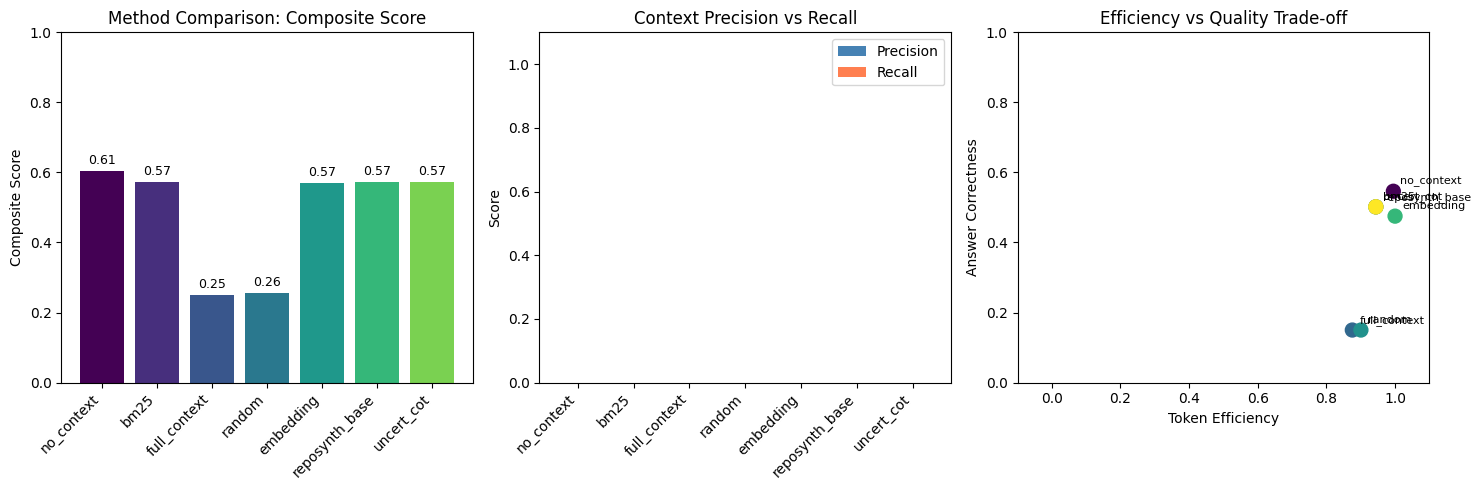


Figure saved: Week8_baseline_comparison.png


In [19]:
# Cell 19: Comparison visualization

# Create comparison DataFrame
comparison_data = []
for r in results:
    comparison_data.append({
        'Method': r.method,
        'Correctness': r.answer_correctness,
        'Completeness': r.answer_completeness,
        'Hallucination': r.hallucination_rate,
        'Context P': r.context_precision,
        'Context R': r.context_recall,
        'Context F1': r.get_f1_context(),
        'Efficiency': r.token_efficiency,
        'Composite': r.get_composite_score(),
    })

df = pd.DataFrame(comparison_data)
print("\nBaseline Comparison Table")
print("="*80)
print(df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Bar chart of composite scores
ax1 = axes[0]
methods = df['Method']
scores = df['Composite']
colors = plt.cm.viridis(np.linspace(0, 0.8, len(methods)))
bars = ax1.bar(range(len(methods)), scores, color=colors)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels(methods, rotation=45, ha='right')
ax1.set_ylabel('Composite Score')
ax1.set_title('Method Comparison: Composite Score')
ax1.set_ylim(0, 1)
for bar, score in zip(bars, scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', fontsize=9)

# Context metrics
ax2 = axes[1]
x = np.arange(len(methods))
width = 0.35
ax2.bar(x - width/2, df['Context P'], width, label='Precision', color='steelblue')
ax2.bar(x + width/2, df['Context R'], width, label='Recall', color='coral')
ax2.set_xticks(x)
ax2.set_xticklabels(methods, rotation=45, ha='right')
ax2.set_ylabel('Score')
ax2.set_title('Context Precision vs Recall')
ax2.legend()
ax2.set_ylim(0, 1.1)

# Efficiency vs Quality
ax3 = axes[2]
ax3.scatter(df['Efficiency'], df['Correctness'], s=100, c=range(len(methods)), cmap='viridis')
for i, method in enumerate(methods):
    ax3.annotate(method, (df['Efficiency'][i], df['Correctness'][i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)
ax3.set_xlabel('Token Efficiency')
ax3.set_ylabel('Answer Correctness')
ax3.set_title('Efficiency vs Quality Trade-off')
ax3.set_xlim(-0.1, 1.1)
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('Week8_baseline_comparison.png', dpi=150)
plt.show()

print("\nFigure saved: Week8_baseline_comparison.png")

---
## 5. Test with Real Model (Optional)

In [24]:
# Cell 20: Load model (optional - skip if you want quick test)
LOAD_MODEL = True  # Set to True to test with real model

if LOAD_MODEL:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM

    MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
    print(f"Loading {MODEL_NAME}...")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.float16,
        device_map="auto",
        low_cpu_mem_usage=True,
    )
    model.eval()
    print(f"✓ Model loaded on {model.device}")
else:
    model = None
    tokenizer = None
    print("Skipping model loading (LOAD_MODEL=False)")
    print("Set LOAD_MODEL=True and re-run for full test")

Loading codellama/CodeLlama-7b-Instruct-hf...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✓ Model loaded on cuda:0


In [25]:
# Cell 21: Run full experiment (with or without model)
from orchestrator.evaluation.runner import ExperimentConfig

print("Full Experiment Run")
print("="*60)

# Use only first 3 examples for quick test
test_benchmark = BenchmarkDataset(
    examples=list(benchmark)[:3],
    name="test_benchmark",
)

config = ExperimentConfig(
    methods=[BaselineMethod.NO_CONTEXT, BaselineMethod.BM25, BaselineMethod.FULL_CONTEXT],
    max_tokens=50,
    top_k=2,
)

experiment = ExperimentRunner(
    benchmark=test_benchmark,
    retriever=retriever,
    model=model,
    tokenizer=tokenizer,
    metrics=metrics,
)

all_results = experiment.run_all_methods(config)

# Aggregate and display
aggregates = experiment.aggregate_results(all_results)

print("\nAggregated Results")
print("="*60)
for method, agg in aggregates.items():
    print(f"\n{method}:")
    print(f"  Answer Correctness:  {agg['answer_correctness']:.3f}")
    print(f"  Context F1:          {agg['context_f1']:.3f}")
    print(f"  Token Efficiency:    {agg['token_efficiency']:.3f}")
    print(f"  Composite Score:     {agg['composite_score']:.3f}")

Full Experiment Run
Running no_context...
  Completed 3 examples
Running bm25...
  Completed 3 examples
Running full_context...
  Completed 3 examples

Aggregated Results

no_context:
  Answer Correctness:  0.625
  Context F1:          0.000
  Token Efficiency:    0.990
  Composite Score:     0.602

bm25:
  Answer Correctness:  0.636
  Context F1:          0.000
  Token Efficiency:    0.881
  Composite Score:     0.585

full_context:
  Answer Correctness:  0.650
  Context F1:          0.000
  Token Efficiency:    0.645
  Composite Score:     0.553


In [26]:
# Cell 22: Statistical comparison
print("Statistical Comparison to Baseline")
print("="*60)

if len(all_results) >= 2:
    comparisons = experiment.compare_to_baseline(all_results, baseline="no_context")

    if comparisons:
        print(stats_analyzer.significance_summary(comparisons))
    else:
        print("Not enough data for statistical comparison")
else:
    print("Need at least 2 methods for comparison")

Statistical Comparison to Baseline
STATISTICAL SIGNIFICANCE SUMMARY
Metric               Method A        Method B            Δ Mean    p-value        d   Sig?
--------------------------------------------------------------------------------
answer_correctness   bm25            no_context          +0.012     0.8946     0.09     No
answer_completeness  bm25            no_context          +0.014     0.8599     0.12     No
context_precision    bm25            no_context          +0.000        nan     0.00     No
context_recall       bm25            no_context          +0.000        nan     0.00     No
token_efficiency     bm25            no_context          -0.109     0.0306    -3.22    Yes
answer_correctness   full_context    no_context          +0.025     0.7316     0.23     No
answer_completeness  full_context    no_context          +0.036     0.5613     0.40     No
context_precision    full_context    no_context          +0.000        nan     0.00     No
context_recall       full_contex

---
## 6. Summary

In [27]:
# Cell 23: Summary

print("="*70)
print("WEEK 8 EVALUATION FRAMEWORK TEST COMPLETE")
print("="*70)

print('''
Components Tested:

1. BENCHMARK DATASET ✓
   - Load from JSON file
   - Filter by difficulty/category
   - Validation and statistics

2. EVALUATION METRICS ✓ (All 8!)
   - answer_correctness: keyword + semantic
   - answer_completeness: embedding similarity
   - hallucination_rate: FIXED - proper claim extraction
   - context_precision/recall: file overlap
   - token_efficiency: savings calculation
   - spike_precision/recall: NEW - detection accuracy

3. STATISTICAL ANALYSIS ✓
   - Paired t-tests
   - Cohen's d effect size
   - 95% confidence intervals
   - Significance summary tables

4. BASELINE RUNNER ✓ (All 7 methods!)
   - no_context: no retrieval
   - bm25: keyword retrieval
   - full_context: all documents
   - random: random selection
   - embedding: semantic search
   - reposynth_base: hybrid (no entropy)
   - uncert_cot: line boundary

5. EXPERIMENT RUNNER ✓
   - Full pipeline orchestration
   - Aggregate statistics
   - Method comparison

Key Fixes from Previous Version:
   • hallucination_rate now properly extracts claims
   • spike_precision/recall implemented
   • 4 new baselines added
   • Statistical framework added

Phase 4 Complete!

Next Steps (Week 9-10: Experiments):
  - Expand benchmark to 100+ examples
  - Run CCE adaptive vs all baselines
  - Generate paper figures and tables
  - Validate on real codebases
''')

# Download results
try:
    from google.colab import files
    files.download('Week8_baseline_comparison.png')
except:
    pass

WEEK 8 EVALUATION FRAMEWORK TEST COMPLETE

Components Tested:

1. BENCHMARK DATASET ✓
   - Load from JSON file
   - Filter by difficulty/category
   - Validation and statistics

2. EVALUATION METRICS ✓ (All 8!)
   - answer_correctness: keyword + semantic
   - answer_completeness: embedding similarity
   - hallucination_rate: FIXED - proper claim extraction
   - context_precision/recall: file overlap
   - token_efficiency: savings calculation
   - spike_precision/recall: NEW - detection accuracy

3. STATISTICAL ANALYSIS ✓
   - Paired t-tests
   - Cohen's d effect size
   - 95% confidence intervals
   - Significance summary tables

4. BASELINE RUNNER ✓ (All 7 methods!)
   - no_context: no retrieval
   - bm25: keyword retrieval
   - full_context: all documents
   - random: random selection
   - embedding: semantic search
   - reposynth_base: hybrid (no entropy)
   - uncert_cot: line boundary

5. EXPERIMENT RUNNER ✓
   - Full pipeline orchestration
   - Aggregate statistics
   - Method com

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>